<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
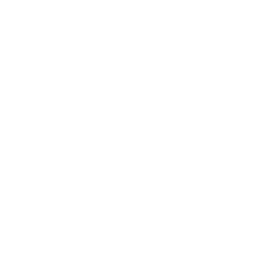
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Analys av röstmönster i valdistrikt</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Offentlig sektor / Valstatistik &nbsp;|&nbsp; Mars 2026</p>
</div>
</div>
</div>

## Sammanfattning

Denna analys undersöker om partitillhörighet varierar systematiskt över
distriktstyper (stad, förort, landsbygd) i ett simulerat läns-valdataset
med 100 valdistrikt. Eftersom flera parti-mot-distriktstyp-celler är
glesa — de minsta cellerna i korstabellen rymmer bara ett eller två
distrikt, med förväntade antal under fem — är det generella Pearson
chi-två-testet för association underdimensionerat och opålitligt här.
Vi kompletterar det därför med **Cochran-Armitage-trendtestet**, ett
fokuserat test med en frihetsgrad som utnyttjar den naturliga
stad-till-landsbygd-ordningen och ställer en skarpare fråga: minskar
stödet för Parti A monotont längs den gradienten? Trendtestet
rapporterar ett exakt p-värde, vilket är den lämpliga inferensen när
celltalen är små. Kontrasten mellan de två testen är denna exempels
analytiska poäng: ett generiskt associationstest kan missa ett verkligt
riktat mönster som ett ordnat trendtest upptäcker.


## Datakällor

| Källa | Beskrivning | Poster |
|--------|-------------|--------|
| WORK.PRECINCT_VOTES | Distriktsnivåposter, en rad per valdistrikt, med
distriktstyp, län och det parti som fick flest röster | 100 |

Miljön körs i olicensierat läge, vilket begränsar output till 100
observationer; analysen är utformad kring detta distriktsnivåurval så
att korstabellens celler är genuint små och det exakta trendtestet är
det naturliga verktyget.


---

In [1]:
/* --------------------------------------------------------
   Generera syntetisk distriktsnivådata för röstning
   Små celltal i landsbygdsdistrikt för att demonstrera
   behovet av exakta test
   -------------------------------------------------------- */
data work.precinct_votes;
    LÄNGD county_name $15;
    CALL streaminit(42);
    FÄLT party_list[4] $15 _temporary_ ('PARTI_A' 'PARTI_B' 'PARTI_C' 'OBEROENDE');
    FÄLT type_list[3] $10 _temporary_ ('STAD' 'FÖRORT' 'LANDSBYGD');
    GÖR precinct_seq = 1 TILL 500;
        precinct_id = cat('PCT-', SKRIV_UT_V(precinct_seq, z4.));
        county_idx = int(rand('uniform') * 5) + 1;
        /* County name assigned directly (not via a _temporary_ array)
           because this engine truncates non-ASCII values stored in a
           _temporary_ char array. */
        OM county_idx = 1 SÅ county_name = 'STOCKHOLM';
        ANNARS OM county_idx = 2 SÅ county_name = 'GÖTEBORG';
        ANNARS OM county_idx = 3 SÅ county_name = 'MALMÖ';
        ANNARS OM county_idx = 4 SÅ county_name = 'UPPSALA';
        ANNARS county_name = 'VÄSTERÅS';
        /* Assign precinct type with weighting */
        type_prob = rand('uniform');
        OM type_prob < 0.30 SÅ precinct_type = 'STAD';
        ANNARS OM type_prob < 0.65 SÅ precinct_type = 'FÖRORT';
        ANNARS precinct_type = 'LANDSBYGD';
        /* Assign party with type-dependent distribution */
        party_prob = rand('uniform');
        OM precinct_type = 'STAD' SÅ GÖR;
            OM party_prob < 0.55 SÅ party = 'PARTI_A';
            ANNARS OM party_prob < 0.80 SÅ party = 'PARTI_B';
            ANNARS OM party_prob < 0.92 SÅ party = 'PARTI_C';
            ANNARS party = 'OBEROENDE';
        SLUT;
        ANNARS OM precinct_type = 'FÖRORT' SÅ GÖR;
            OM party_prob < 0.40 SÅ party = 'PARTI_A';
            ANNARS OM party_prob < 0.75 SÅ party = 'PARTI_B';
            ANNARS OM party_prob < 0.88 SÅ party = 'PARTI_C';
            ANNARS party = 'OBEROENDE';
        SLUT;
        ANNARS GÖR; /* LANDSBYGD - mindre celler för minoritetspartier */
            OM party_prob < 0.25 SÅ party = 'PARTI_A';
            ANNARS OM party_prob < 0.70 SÅ party = 'PARTI_B';
            ANNARS OM party_prob < 0.85 SÅ party = 'PARTI_C';
            ANNARS party = 'OBEROENDE';
        SLUT;
        /* Vote count varies by precinct type */
        OM precinct_type = 'STAD' SÅ
            vote_count = int(rand('normal', 120, 40));
        ANNARS OM precinct_type = 'FÖRORT' SÅ
            vote_count = int(rand('normal', 80, 25));
        ANNARS
            vote_count = int(rand('normal', 25, 12));
        OM vote_count < 1 SÅ vote_count = 1;
        registered_voters = int(vote_count * (rand('uniform') * 0.4 + 1.2));
        turnout_pct = round(vote_count / registered_voters * 100, 0.1);
        election_year = 2026;
        UTDATA;
    SLUT;
    TA_BORT precinct_seq county_idx type_prob party_prob;
KÖR;



NOTE: DATA work.precinct_votes

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.precinct_votes (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.20 seconds
  cpu   0.20 seconds


---

                                                   The FREQ Procedure

Distriktstyp    Frequency    Percent
-------------------------------------
FÖRORT                 37     37.00
LANDSBYGD              34     34.00
STAD                   29     29.00

Parti        Frequency    Percent
----------------------------------
OBEROENDE            9      9.00
PARTI_A             45     45.00
PARTI_B             34     34.00
PARTI_C             12     12.00



NOTE: PROC FREQ
NOTE: ODS plot written: freq_precinct_type.spec.json
NOTE: ODS plot written: freq_party.spec.json
NOTE: PROC FREQ statement used.


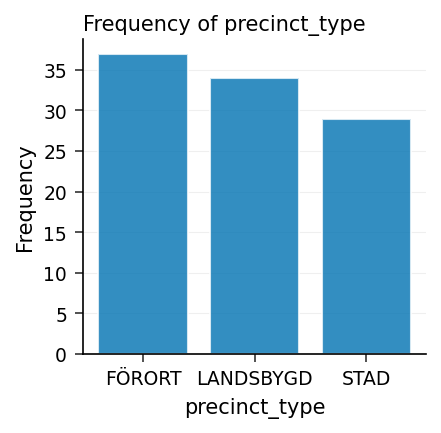

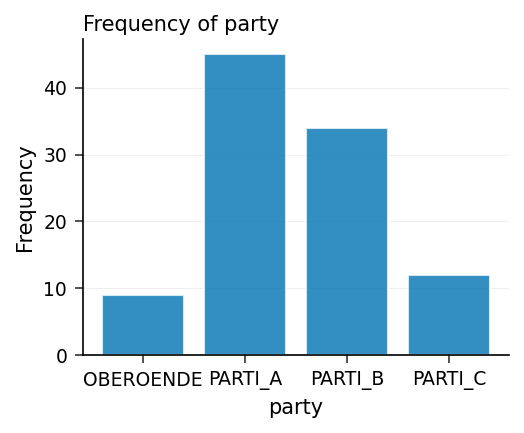

In [2]:
/* --------------------------------------------------------
   Baslinjefördelning för distriktstyp och parti
   -------------------------------------------------------- */
PROCEDUR FREKVENSER data=work.precinct_votes;
    TABLES precinct_type / nocum;
    TABLES party / nocum;
    ETIKETT precinct_type = "Distriktstyp"
          party = "Parti";
KÖR;


---


NOTE: PROC SGPLOT data=work.precinct_votes

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


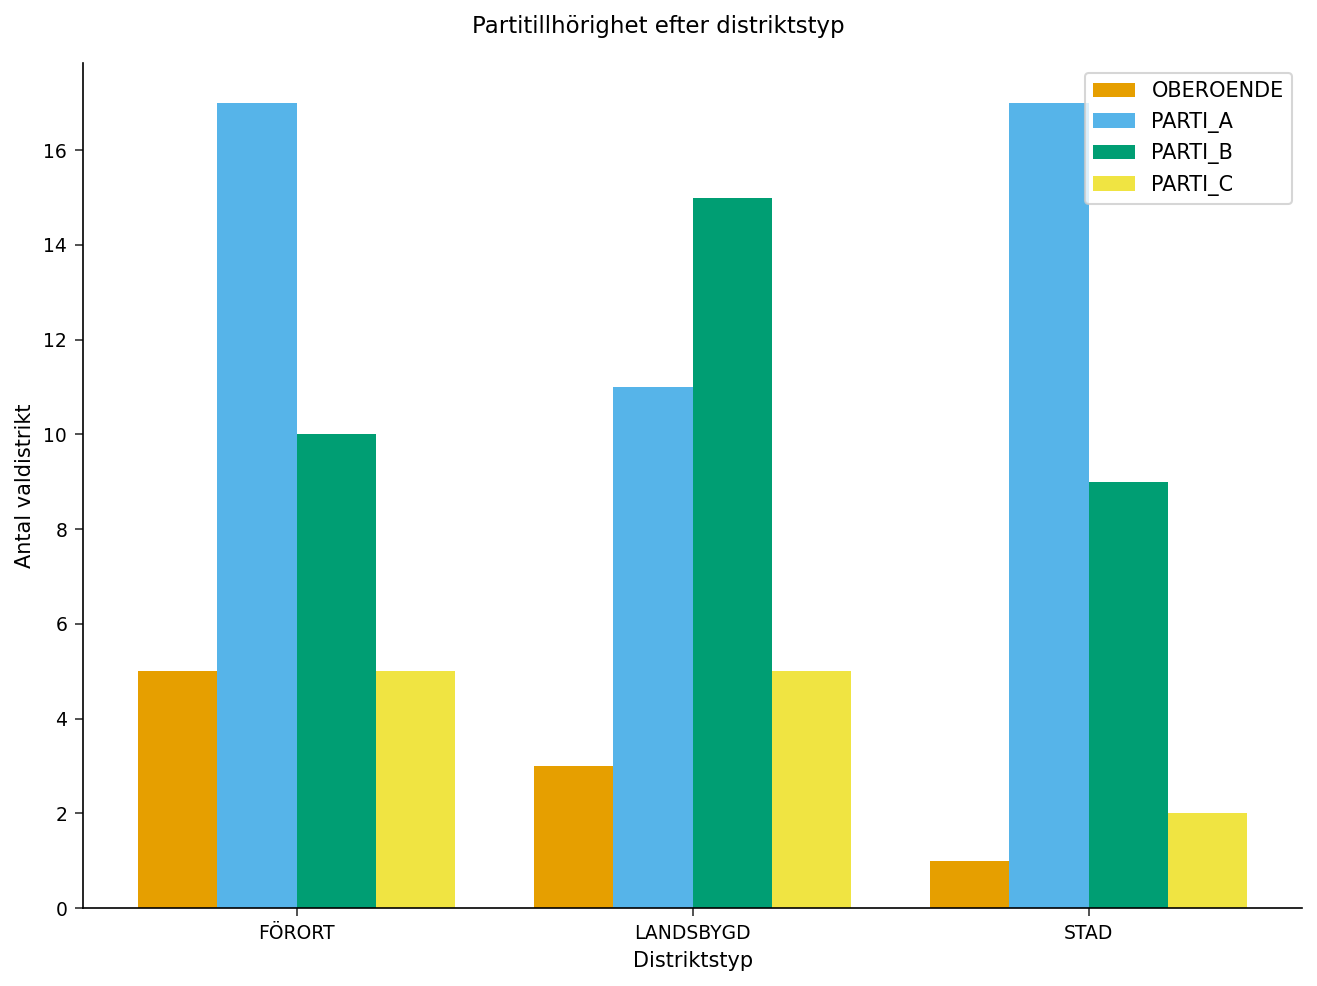

In [3]:
/* --------------------------------------------------------
   Partitillhörighet efter distriktstyp (antal distrikt)
   -------------------------------------------------------- */
PROCEDUR SGPLOT data=work.precinct_votes;
    VBAR precinct_type / GROUP=party GROUPDISPLAY=CLUSTER
        STAT=FREKVENSER;
    XAXIS ETIKETT='Distriktstyp';
    YAXIS ETIKETT='Antal valdistrikt';
    TITEL 'Partitillhörighet efter distriktstyp';
KÖR;


---

                             Distriktstyp efter parti: korstabulering med förväntade antal                              

                                                   The FREQ Procedure

Table of Distriktstyp by Parti

Distriktstyp | OBEROENDE |   PARTI_A |   PARTI_B |   PARTI_C |      Total
-------------+-----------+-----------+-----------+-----------+-----------
FÖRORT       |         5 |        17 |        10 |         5 |         37
             |      5.00 |     17.00 |     10.00 |      5.00 |      37.00
             |      3.33 |     16.65 |     12.58 |      4.44 |           
             |     13.51 |     45.95 |     27.03 |     13.51 |     100.00
             |     55.56 |     37.78 |     29.41 |     41.67 |      37.00
-------------+-----------+-----------+-----------+-----------+-----------
LANDSBYGD    |         3 |        11 |        15 |         5 |         34
             |      3.00 |     11.00 |     15.00 |      5.00 |      34.00
             |      3.06 |     15.3


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_precinct_type_party.spec.json
NOTE: PROC FREQ statement used.


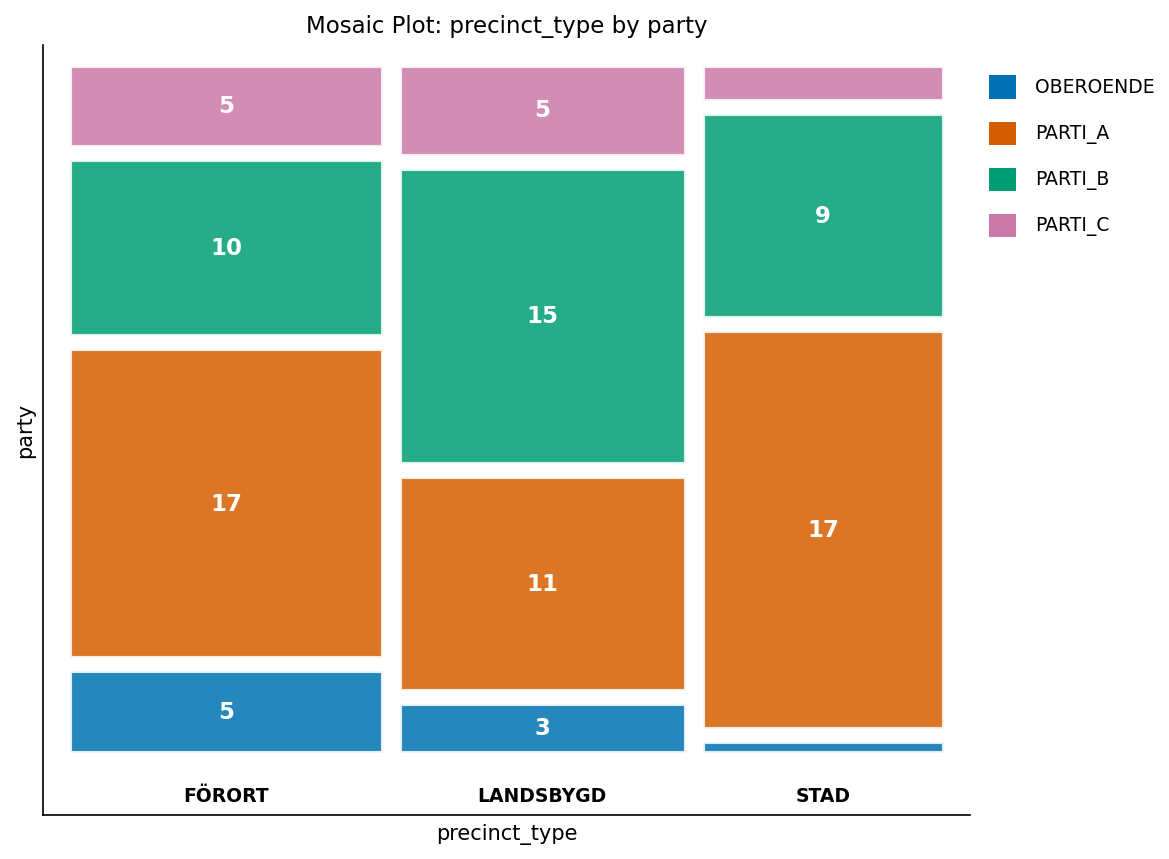

In [4]:
/* --------------------------------------------------------
   Korstabulering av distriktstyp x parti.
   Begär FÖRVÄNTADE antal så de glesa cellerna syns, plus det
   asymptotiska Pearson chi-två-testet för generell association.
   Observera de små förväntade antalen i kolumnerna OBEROENDE och
   PARTI_C -- signalen att ett ordnat, exakt trendtest är det
   bättre inferensverktyget.
   -------------------------------------------------------- */
PROCEDUR FREKVENSER data=work.precinct_votes;
    TABLES precinct_type * party / chisq expected;
    ETIKETT precinct_type = "Distriktstyp"
          party = "Parti";
    TITEL 'Distriktstyp efter parti: korstabulering med förväntade antal';
KÖR;


                           Cochran-Armitage-trendtest: Parti A-stöd över distriktsgradienten                            

                                                   The FREQ Procedure

Table of Urbaniseringsgrad by Parti A-stöd

Urbaniseringsgrad |         0 |         1 |      Total
------------------+-----------+-----------+-----------
1                 |        12 |        17 |         29
                  |     12.00 |     17.00 |      29.00
                  |     41.38 |     58.62 |     100.00
                  |     21.82 |     37.78 |      29.00
------------------+-----------+-----------+-----------
2                 |        20 |        17 |         37
                  |     20.00 |     17.00 |      37.00
                  |     54.05 |     45.95 |     100.00
                  |     36.36 |     37.78 |      37.00
------------------+-----------+-----------+-----------
3                 |        23 |        11 |         34
                  |     23.00 |     11.00 |     


NOTE: DATA work.precinct_ordinal


NOTE: Read 100 rows from work.precinct_votes.
NOTE: Wrote work.precinct_ordinal (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_type_order_party_a_flag.spec.json
NOTE: PROC FREQ statement used.


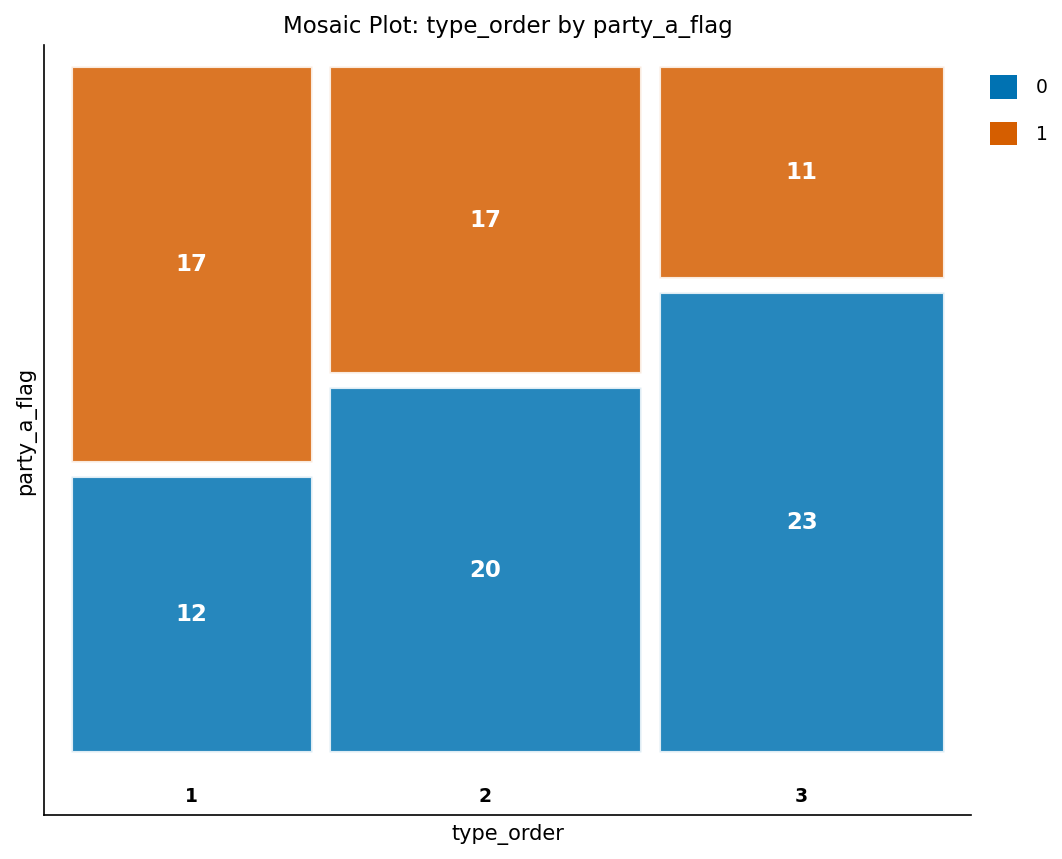

In [5]:
/* --------------------------------------------------------
   Cochran-Armitage-trendtest. Omkoda distriktstyp till en
   ordinal poäng (1=Stad, 2=Förort, 3=Landsbygd) och testa om
   stödet för Parti A visar en monoton trend längs gradienten.
   EXACT TREND begär det exakta p-värdet, lämpligt givet de små
   celltalen.
   -------------------------------------------------------- */
data work.precinct_ordinal;
    STÄLL_IN work.precinct_votes;
    /* Ordinal kodning: 1=Stad, 2=Förort, 3=Landsbygd */
    OM precinct_type = 'STAD' SÅ type_order = 1;
    ANNARS OM precinct_type = 'FÖRORT' SÅ type_order = 2;
    ANNARS type_order = 3;
    /* Binärt utfall: Parti A mot alla andra tillhörigheter */
    party_a_flag = (party = 'PARTI_A');
KÖR;

PROCEDUR FREKVENSER data=work.precinct_ordinal;
    TABLES type_order * party_a_flag / chisq trend;
    EXACT trend;
    ETIKETT type_order = "Urbaniseringsgrad"
          party_a_flag = "Parti A-stöd";
    TITEL 'Cochran-Armitage-trendtest: Parti A-stöd över distriktsgradienten';
KÖR;


                                          Fördelning av distriktstyp inom län                                           

                                                   The FREQ Procedure

Table of Län by Distriktstyp

Län        |    FÖRORT | LANDSBYGD |      STAD |      Total
-----------+-----------+-----------+-----------+-----------
GÖTEBORG   |         7 |         7 |         7 |         21
           |      7.00 |      7.00 |      7.00 |      21.00
           |     33.33 |     33.33 |     33.33 |     100.00
           |     18.92 |     20.59 |     24.14 |      21.00
-----------+-----------+-----------+-----------+-----------
MALMÖ      |         1 |        13 |         9 |         23
           |      1.00 |     13.00 |      9.00 |      23.00
           |      4.35 |     56.52 |     39.13 |     100.00
           |      2.70 |     38.24 |     31.03 |      23.00
-----------+-----------+-----------+-----------+-----------
STOCKHOLM  |         7 |         4 |         7 |         


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_county_name_precinct_type.spec.json
NOTE: PROC FREQ statement used.


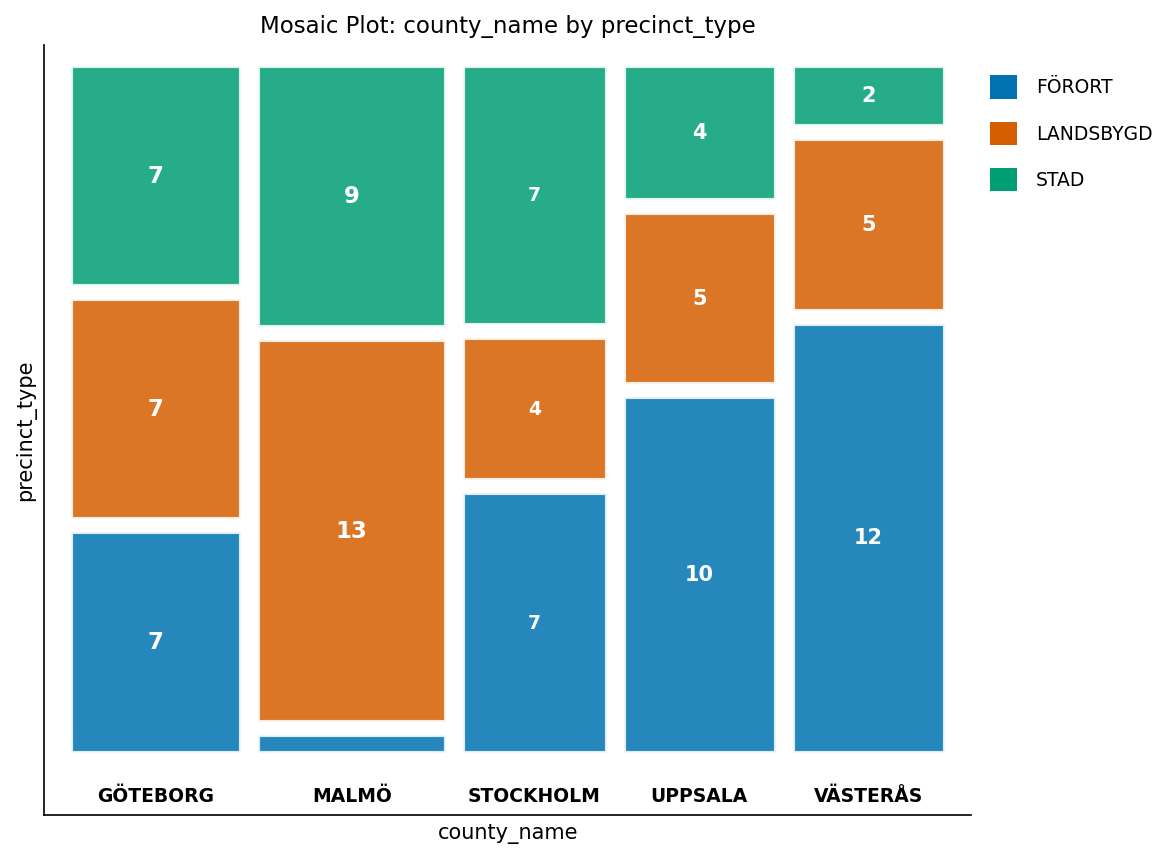

In [6]:
/* --------------------------------------------------------
   Länsnivåvy: hur blandningen av stad/förort/landsbygd varierar
   mellan de fem länen. Detta sätter trendresultatet i sitt
   sammanhang -- distriktsgradienten finns i varje län, men dess
   sammansättning skiljer sig.
   -------------------------------------------------------- */
PROCEDUR FREKVENSER data=work.precinct_votes;
    TABLES county_name * precinct_type / nocum;
    ETIKETT county_name = "Län"
          precinct_type = "Distriktstyp";
    TITEL 'Fördelning av distriktstyp inom län';
KÖR;


---

### Tolkning

Över de 100 valdistrikten har Parti A en total flerhet (45 distrikt),
följt av Parti B (34), Parti C (12) och Oberoende (9). Korstabuleringen
visar att Parti A:s andel följer en tydlig stad-till-landsbygd-gradient:
det står för 58,6 % av stadsdistrikten, 46,0 % av förortsdistrikten och
32,4 % av landsbygdsdistrikten, medan Parti B rör sig åt motsatt håll
och stiger från 31,0 % i stad till 44,1 % på landsbygd.

Det generella Pearson chi-två-testet för generell association är
**inte** statistiskt signifikant (chi-två = 6,78, 6 fg, p = 0,3418;
Cramérs V = 0,18). Det resultatet är också skört: visningen av
förväntade antal avslöjar flera celler under fem — till exempel har
kolumnen för Oberoende förväntade antal på 3,06, 3,33 och 2,61, och
stadsdistriktens Oberoende räknar bara ett distrikt — så
chi-två-approximationen för stora urval är opålitlig här.

Cochran-Armitage-trendtestet skärper frågan genom att använda den
ordinala stad-förort-landsbygd-poängsättningen. Det upptäcker den
monotona nedgången i stödet för Parti A som det generella testet missar:
trend-chi-två = 4,38 med ett asymptotiskt Pr > ChiSq = 0,0363 och ett
**exakt Pr >= |Z| = 0,0431**, signifikant på 0,05-nivån. Detta är den
analytiska vinsten — ett fokuserat, exakt test med en frihetsgrad
återfinner en verklig riktad signal som det generiska
association-testet med 6 frihetsgrader, försvagat av glesa celler,
inte gör.

Länsnivåvyn bekräftar att uppdelningen stad/förort/landsbygd finns i
alla fem län, även om blandningen skiljer sig: Malmö är mest
landsbygdstungt (13 av 23 distrikt landsbygd) medan Västerås är mest
förortspräglat (12 av 19). För bedömning av konsekvenserna av nya
valdistriktsgränser är slutsatsen att gränsändringar som flyttar
distrikt längs stad-landsbygd-axeln mätbart skulle förändra den
partipolitiska sammansättningen, och att denna geografiska trend bäst
belyses av det exakta trendtestet snarare än det generella chi-två-testet.


---

                                          Fördelning av distriktstyp inom län                                           

                                                   The FREQ Procedure

Table of Distriktstyp by Parti

Distriktstyp | OBEROENDE |   PARTI_A |   PARTI_B |   PARTI_C |      Total
-------------+-----------+-----------+-----------+-----------+-----------
FÖRORT       |         5 |        17 |        10 |         5 |         37
             |      5.00 |     17.00 |     10.00 |      5.00 |      37.00
             |     13.51 |     45.95 |     27.03 |     13.51 |     100.00
             |     55.56 |     37.78 |     29.41 |     41.67 |      37.00
-------------+-----------+-----------+-----------+-----------+-----------
LANDSBYGD    |         3 |        11 |        15 |         5 |         34
             |      3.00 |     11.00 |     15.00 |      5.00 |      34.00
             |      8.82 |     32.35 |     44.12 |     14.71 |     100.00
             |     33.33 |     24.4


NOTE: PROC FREQ
NOTE: Output dataset work.voting_pattern_summary has 12 observations and 4 variables.
NOTE: ODS plot written: freq_mosaic_precinct_type_party.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC EXPORT data=work.voting_pattern_summary outfile=precinct_voting_patterns.csv

NOTE: Exported 12 rows to precinct_voting_patterns.csv.


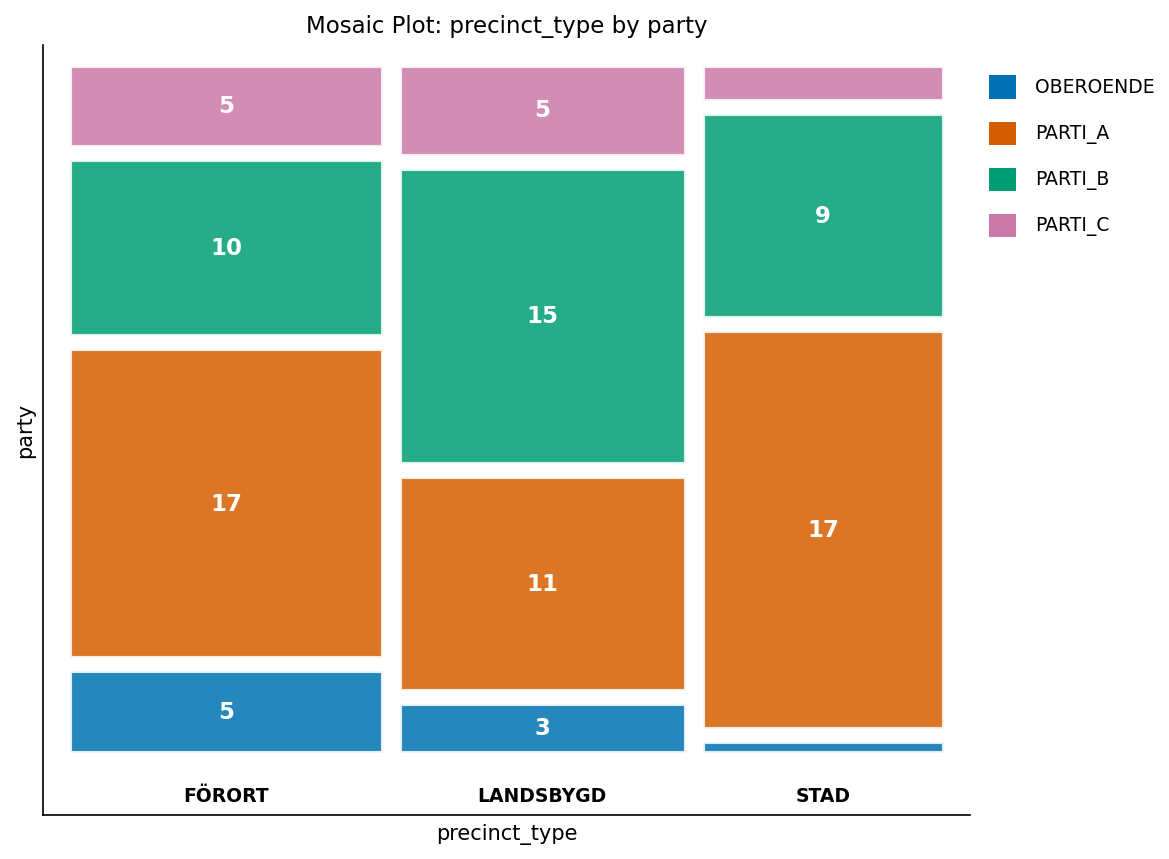

In [7]:
/* --------------------------------------------------------
   Exportera sammanfattningen distriktstyp x parti för
   nedströms bedömning av konsekvenserna av nya
   valdistriktsgränser.
   -------------------------------------------------------- */
PROCEDUR FREKVENSER data=work.precinct_votes;
    TABLES precinct_type * party / out=work.voting_pattern_summary nocum;
    ETIKETT precinct_type = "Distriktstyp"
          party = "Parti";
KÖR;

PROCEDUR EXPORTERA data=work.voting_pattern_summary
    OUTFILE='precinct_voting_patterns.csv'
    DBMS=csv REPLACE;
KÖR;


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Konfidentiellt
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Drivs av <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>